In [1]:
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.datasets import fetch_covtype
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, log_loss
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch import Tensor

import torch._dynamo
import torch.utils.benchmark as benchmark
from torch.optim import Optimizer
from torchinfo import summary
from torch.autograd import Function
import torch._inductor.metrics as metrics

In [2]:
def zeropower_via_newtonschulz5(G: Tensor, steps: int) -> Tensor:
    assert G.ndim >= 2
    a, b, c = 3.4445, -4.7750, 2.0315
    X = G.clone().float()
    if G.size(-2) > G.size(-1):
        X = X.mT
    X = X / (X.norm(dim=(-2, -1), keepdim=True) + 1e-7)
    for _ in range(steps):
        A = X @ X.mT
        B = b * A + c * A @ A
        X = a * X + B @ X
    if G.size(-2) > G.size(-1):
        X = X.mT
    return X

class Muon(Optimizer):
    def __init__(self, params, lr=0.02, weight_decay=0.01, momentum=0.95, nesterov=True, ns_steps=5):
        defaults = dict(lr=lr, weight_decay=weight_decay, momentum=momentum, nesterov=nesterov, ns_steps=ns_steps)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            lr = group["lr"]
            weight_decay = group["weight_decay"]
            momentum = group["momentum"]
            nesterov = group["nesterov"]
            ns_steps = group["ns_steps"]

            for p in group["params"]:
                if p.grad is None:
                    continue
                g = p.grad.data

                if g.ndim < 2:
                    continue  # skip scalars, biases, etc.

                state = self.state[p]
                if "momentum_buffer" not in state:
                    state["momentum_buffer"] = torch.zeros_like(g)

                buf = state["momentum_buffer"]
                buf.mul_(momentum).add_(g)

                if nesterov:
                    g = g + momentum * buf
                else:
                    g = buf

                if g.ndim == 4:
                    g = g.view(g.size(0), -1)

                g = zeropower_via_newtonschulz5(g, steps=ns_steps).view_as(p)

                p.mul_(1 - lr * weight_decay)
                p.add_(g, alpha=-lr)

In [3]:
torch._dynamo.config.cache_size_limit = 16

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device = torch.device("cpu")

In [4]:
df = sns.load_dataset('diamonds')
df = df[['carat', 'depth', 'table', 'price', 'x', 'y', 'z', 'cut']]

df['cut'] = (df['cut'] == 'Ideal').astype(int)

X = df.drop('cut', axis=1)
y = df['cut']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long).to(device)

print(X.shape)
print(y.shape)

ideal_percentage = df['cut'].mean() * 100
print(f"Percentage of diamonds with 'Ideal' cut: {ideal_percentage:.2f}%")

model = LogisticRegression(penalty='l2', C=0.001, max_iter=10000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

y_pred_proba = model.predict_proba(X_test)
loss = log_loss(y_test, y_pred_proba)

print(f"Test Accuracy: {accuracy * 100:.2f}%")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Ideal', 'Ideal']))
print(model.coef_)
print(f"Log Loss: {loss:.6f}")

(53940, 7)
(53940,)
Percentage of diamonds with 'Ideal' cut: 39.95%
Test Accuracy: 79.30%
Classification Report:
              precision    recall  f1-score   support

   Not Ideal       0.82      0.85      0.83      6496
       Ideal       0.75      0.71      0.73      4292

    accuracy                           0.79     10788
   macro avg       0.79      0.78      0.78     10788
weighted avg       0.79      0.79      0.79     10788

[[-0.15688782 -0.46189194 -1.57368125  0.22509094 -0.08309788 -0.03167662
  -0.08671039]]
Log Loss: 0.451068


/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered

In [6]:
def train(model, criterion, optimizers, epochs):
    print(summary(model, input_data=X_train_tensor))

    torch.set_printoptions(threshold=float('inf'))
    for name, param in model.named_parameters():
        print(name)
        print(param)

    @torch._dynamo.explain
    def run_model(x):
        return model(x)

    print(run_model(X_train_tensor)) # type: ignore

    best_test_loss = float('inf')

    train_losses = []
    test_losses = []

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    schedulers = [
        torch.optim.lr_scheduler.LinearLR(opt, start_factor=1.0, end_factor=0.05, total_iters=epochs)
        for opt in optimizers
    ]

    for epoch in range(1, epochs + 1):
        model.train()
        for opt in optimizers:
            opt.zero_grad()

        train_outputs = model(X_train_tensor)
        train_loss = criterion(train_outputs, y_train_tensor)
        train_loss.backward()

        for opt in optimizers:
            opt.step()

        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test_tensor)
            test_loss = criterion(test_outputs, y_test_tensor)
            test_predictions = torch.argmax(test_outputs, dim=1)
            test_accuracy = (test_predictions == y_test_tensor).sum().item() / y_test_tensor.size(0)

        train_losses.append(train_loss.item())
        test_losses.append(test_loss.item())

        if test_loss.item() < best_test_loss:
            best_test_loss = test_loss.item()

        for scheduler in schedulers:
            scheduler.step()

        if epoch % 1 == 0:
            print(f"Epoch {epoch}/{epochs}, Train Loss: {train_loss.item():.32f}, Test Loss: {test_loss.item():.8f}, Test Accuracy: {test_accuracy:.4f}")

    if torch.cuda.is_available():
        gc.collect()
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

        print(f"[GPU] Peak memory allocated: {torch.cuda.max_memory_allocated() / 1024 ** 2:.2f} MB")
        print(f"[GPU] Peak memory reserved: {torch.cuda.max_memory_reserved() / 1024 ** 2:.2f} MB")

    print()
    print(f"Lowest Test Loss: {best_test_loss:.8f}")

    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Test Loss Over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()  

In [7]:
class CustomActivation(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.a = nn.Parameter(torch.full((num_features,), 1.0))
        self.b = nn.Parameter(torch.full((num_features,), 1.0))

    def forward(self, x):
        return torch.where(x >= 0, self.a * x, self.b * x)

In [ ]:
class StableNN(nn.Module):
    def __init__(self, n, num_layers=2, add=16):
        super().__init__()
        self.n = n
        self.num_layers = num_layers
        self.initial_norm = nn.BatchNorm1d(n, affine=False, track_running_stats=True, momentum=1.0)

        self.blocks = nn.ModuleList()
        for i in range(num_layers):
            in_features = n + i * add
            linear = nn.Linear(in_features, add, bias=False)

            with torch.no_grad():
                weight = torch.zeros(add, in_features)
                weight[:, :n] = torch.randn(add, n)
                linear.weight.copy_(weight)

            block = nn.Sequential(
                linear,
                nn.BatchNorm1d(add, affine=False, track_running_stats=True, momentum=1.0),
                CustomActivation(add),
                nn.BatchNorm1d(add, affine=False, track_running_stats=True, momentum=1.0),
            )
            self.blocks.append(block)

        self.final_linear = nn.Linear(n + num_layers * add, 1, bias=True)
        with torch.no_grad():
            self.final_linear.weight.fill_(0.0)
            self.final_linear.bias.fill_(0.0)

    def forward(self, x):
        x = self.initial_norm(x)
        features = [x]

        for i in range(self.num_layers):
            inputs = torch.cat(features, dim=1)
            out = self.blocks[i](inputs)
            features.append(out)

        final_input = torch.cat(features, dim=1)
        out = self.final_linear(final_input)
        return torch.cat([out, -out], dim=1)


Layer (type:depth-idx)                        Output Shape              Param #
OptimizedModule                               [43152, 2]                --
├─StableNN: 1-1                               [43152, 2]                --
│    └─BatchNorm1d: 2-1                       [43152, 7]                --
│    └─ModuleList: 2-2                        --                        --
│    │    └─Sequential: 3-1                   [43152, 16]               144
│    │    └─Sequential: 3-2                   [43152, 16]               400
│    │    └─Sequential: 3-3                   [43152, 16]               656
│    │    └─Sequential: 3-4                   [43152, 16]               912
│    │    └─Sequential: 3-5                   [43152, 16]               1,168
│    │    └─Sequential: 3-6                   [43152, 16]               1,424
│    │    └─Sequential: 3-7                   [43152, 16]               1,680
│    │    └─Sequential: 3-8                   [43152, 16]               1,936
│   

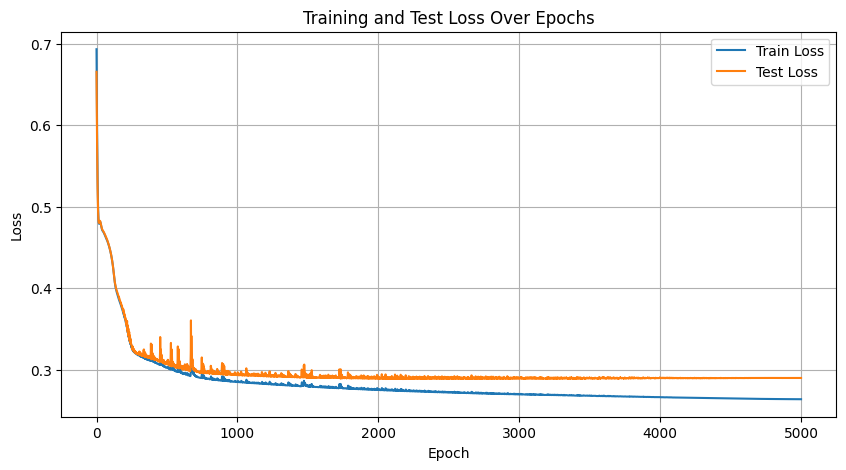

_orig_mod.blocks.0.0.weight
Parameter containing:
tensor([[-8.2769e-01, -7.5553e-01, -9.1673e-01,  2.2285e-02,  1.6828e+00,
          1.3214e+00, -1.9332e-01],
        [-6.1879e-02, -5.5901e-01, -1.7394e-01, -1.4317e+00, -6.8556e-01,
          5.9002e-02,  3.2342e-01],
        [-1.4973e+00, -6.2322e-01,  1.0371e+00,  9.7574e-01,  1.0615e+00,
         -3.1659e-01, -4.9375e-01],
        [ 8.0713e-01, -1.4700e+00,  2.8383e-01,  4.3018e-02,  1.5852e-01,
         -3.2001e-01, -3.1523e-01],
        [-7.1811e-01, -7.2536e-01, -7.3679e-01, -4.0224e-01,  2.3686e-01,
         -8.7380e-01, -3.8658e-01],
        [-1.2786e+00, -1.7019e+00, -1.1111e+00,  9.4385e-02,  1.3815e+00,
         -4.6500e-01, -8.0968e-01],
        [-1.2147e+00, -5.5612e-01,  1.9322e+00,  8.2636e-02,  4.6837e-01,
          1.4299e+00,  1.7540e+00],
        [-6.6726e-01, -7.7124e-01,  1.8017e-01, -4.6078e-01,  3.2061e-01,
         -8.2567e-01, -1.3251e+00],
        [-5.7870e-01,  1.1933e+00,  6.0463e-01,  7.7940e-01, -3.5476e-

In [36]:
model = torch.compile(StableNN(n=X.shape[1], num_layers=8).to(device))
criterion = nn.CrossEntropyLoss()

optimizers = [
    optim.Adam(model.parameters()),
]

train(model, criterion, optimizers, epochs=5000)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Layer (type:depth-idx)                        Output Shape              Param #
OptimizedModule                               [43152, 2]                --
├─StableNN: 1-1                               [43152, 2]                --
│    └─BatchNorm1d: 2-1                       [43152, 7]                --
│    └─ModuleList: 2-2                        --                        --
│    │    └─Sequential: 3-1                   [43152, 16]               144
│    │    └─Sequential: 3-2                   [43152, 16]               400
│    │    └─Sequential: 3-3                   [43152, 16]               656
│    │    └─Sequential: 3-4                   [43152, 16]               912
│    │    └─Sequential: 3-5                   [43152, 16]               1,168
│    │    └─Sequential: 3-6                   [43152, 16]               1,424
│    │    └─Sequential: 3-7                   [43152, 16]               1,680
│    │    └─Sequential: 3-8                   [43152, 16]               1,936
│   

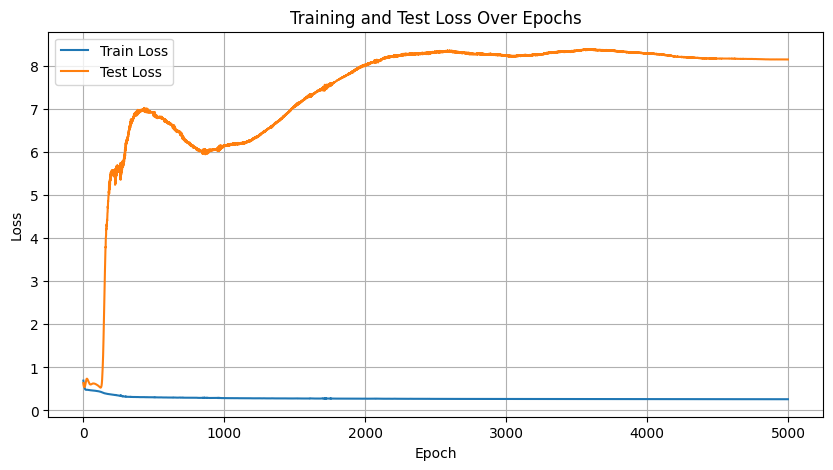

_orig_mod.blocks.0.0.weight
Parameter containing:
tensor([[-0.7563, -1.8715, -1.0492, -1.5357,  0.0454, -0.1029, -0.8477],
        [-0.0277, -0.7396, -1.3092,  1.8705,  0.4814,  0.3692,  1.1207],
        [ 0.3785,  0.2217, -1.0869,  1.4179, -0.7050,  0.4200, -0.0246],
        [ 0.6482, -1.2084, -1.2909, -2.4662,  0.0312,  0.1976,  0.6020],
        [ 1.4543,  0.2819,  0.9869, -1.6845, -0.9826,  0.4183, -0.5739],
        [ 0.1369, -1.4733,  0.5652,  0.8667,  1.9646, -0.4736,  2.0379],
        [ 1.4347,  0.4701,  0.7804,  0.1247,  0.0692,  0.4639, -1.1663],
        [-1.0361, -0.7651,  2.2554,  0.1603, -2.0057,  0.0365,  1.3452],
        [-0.8086,  1.5873, -0.0946,  0.6704, -0.8447, -0.3201, -1.0096],
        [-0.9689, -0.0218,  0.1851, -0.2832,  1.2253,  0.8860,  0.6642],
        [-0.0744,  0.2829, -0.7229,  2.6164, -0.9250,  0.4367, -0.7202],
        [-0.1944,  1.4637, -1.1719,  0.2457,  1.1644, -0.5615, -0.5729],
        [ 0.9997, -0.6320,  1.2775, -2.4109, -1.9812,  0.6369, -0.5185],
 

In [34]:
model = torch.compile(StableNN(n=X.shape[1], num_layers=8).to(device))
criterion = nn.CrossEntropyLoss()

optimizers = [
    optim.Adam(model.parameters()),
]

train(model, criterion, optimizers, epochs=5000)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Layer (type:depth-idx)                        Output Shape              Param #
OptimizedModule                               [43152, 2]                --
├─StableNN: 1-1                               [43152, 2]                --
│    └─BatchNorm1d: 2-1                       [43152, 7]                --
│    └─ModuleList: 2-2                        --                        --
│    │    └─Sequential: 3-1                   [43152, 16]               144
│    │    └─Sequential: 3-2                   [43152, 16]               400
│    │    └─Sequential: 3-3                   [43152, 16]               656
│    │    └─Sequential: 3-4                   [43152, 16]               912
│    │    └─Sequential: 3-5                   [43152, 16]               1,168
│    │    └─Sequential: 3-6                   [43152, 16]               1,424
│    │    └─Sequential: 3-7                   [43152, 16]               1,680
│    │    └─Sequential: 3-8                   [43152, 16]               1,936
│   

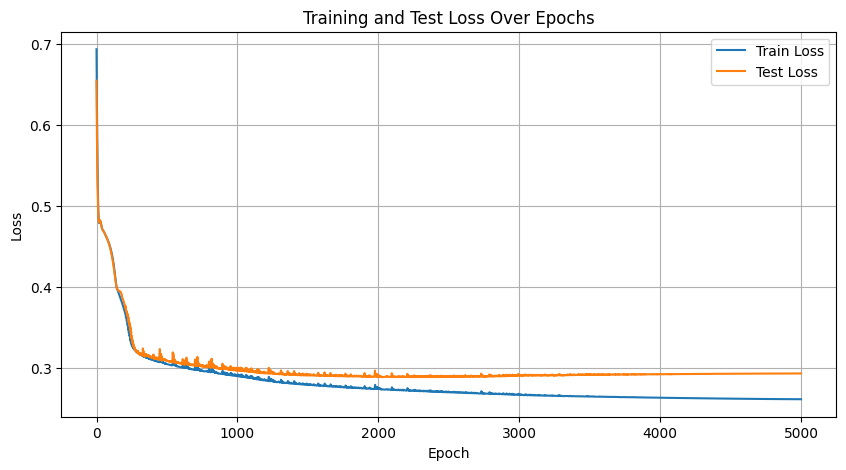

_orig_mod.blocks.0.0.weight
Parameter containing:
tensor([[ 1.8494,  0.8552,  0.2745,  1.6483, -0.5875, -0.0657, -1.4948],
        [ 0.6685, -0.8937, -0.4789, -0.4650, -1.2116,  1.3126, -1.5181],
        [ 0.5895,  2.2307, -1.0091,  0.3696, -0.7536,  0.3617, -0.9421],
        [ 0.0339, -0.7993, -0.1475, -1.8056, -0.2515,  0.5322,  0.3424],
        [ 0.9949,  0.7208,  0.7242, -0.4947,  1.5242,  1.0447, -0.6574],
        [ 0.9199, -0.6929, -1.3550, -0.7835, -1.3547,  0.3360,  0.5400],
        [ 0.5962,  0.7282, -0.2908,  1.2712,  0.8003, -1.7057, -0.3001],
        [ 0.6033, -0.5927,  0.1127,  0.7780, -0.3914,  0.6115, -1.5080],
        [-0.4778,  0.8036,  0.2480,  0.1519, -1.0609,  1.0421,  0.3192],
        [-0.2955,  0.1543,  1.1499, -0.3382,  0.6901,  0.3164,  0.0496],
        [ 1.1379,  1.0487,  0.4704, -0.7760, -0.6058,  1.3512,  1.3431],
        [-0.2061,  1.5923,  0.2468,  0.4302, -1.4923, -0.0385,  0.0659],
        [ 1.0510,  0.2747, -0.3374,  0.0934,  1.0345, -1.5960,  1.8361],
 

In [32]:
model = torch.compile(StableNN(n=X.shape[1], num_layers=8).to(device))
criterion = nn.CrossEntropyLoss()

optimizers = [
    optim.Adam(model.parameters()),
]

train(model, criterion, optimizers, epochs=5000)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

In [30]:
model = torch.compile(StableNN(n=X.shape[1], num_layers=4).to(device))
criterion = nn.CrossEntropyLoss()

optimizers = [
    # optim.Rprop(model.parameters(), lr=0.0, step_sizes=(torch.finfo(torch.float32).smallest_normal, torch.inf)) # type: ignore
]

train(model, criterion, optimizers, epochs=5000)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Layer (type:depth-idx)                        Output Shape              Param #
OptimizedModule                               [43152, 2]                --
├─StableNN: 1-1                               [43152, 2]                --
│    └─BatchNorm1d: 2-1                       [43152, 7]                --
│    └─ModuleList: 2-2                        --                        --
│    │    └─Sequential: 3-1                   [43152, 16]               144
│    │    └─Sequential: 3-2                   [43152, 16]               400
│    │    └─Sequential: 3-3                   [43152, 16]               656
│    │    └─Sequential: 3-4                   [43152, 16]               912
│    └─Linear: 2-3                            [43152, 1]                72
Total params: 2,184
Trainable params: 2,184
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 88.72
Input size (MB): 1.21
Forward/backward pass size (MB): 44.53
Params size (MB): 0.01
Estimated Total Size (MB): 45.75
_orig_mod.block

KeyboardInterrupt: 

In [ ]:
model = torch.compile(StableNN(n=X.shape[1], num_layers=4).to(device))
criterion = nn.CrossEntropyLoss()

optimizers = [
    optim.Rprop(model.parameters(), lr=0.0, step_sizes=(torch.finfo(torch.float32).smallest_normal, torch.inf)) # type: ignore
    # optim.Adam(model.parameters())
]

train(model, criterion, optimizers, epochs=5000)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Layer (type:depth-idx)                        Output Shape              Param #
OptimizedModule                               [43152, 2]                --
├─StableNN: 1-1                               [43152, 2]                --
│    └─BatchNorm1d: 2-1                       [43152, 7]                --
│    └─ModuleList: 2-2                        --                        --
│    │    └─Sequential: 3-1                   [43152, 8]                72
│    │    └─Sequential: 3-2                   [43152, 8]                136
│    │    └─Sequential: 3-3                   [43152, 8]                200
│    │    └─Sequential: 3-4                   [43152, 8]                264
│    └─Linear: 2-3                            [43152, 1]                40
Total params: 712
Trainable params: 712
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 27.96
Input size (MB): 1.21
Forward/backward pass size (MB): 22.44
Params size (MB): 0.00
Estimated Total Size (MB): 23.65
_orig_mod.blocks.0.0

KeyboardInterrupt: 

Layer (type:depth-idx)                        Output Shape              Param #
OptimizedModule                               [43152, 2]                --
├─StableNN: 1-1                               [43152, 2]                --
│    └─BatchNorm1d: 2-1                       [43152, 7]                --
│    └─ModuleList: 2-2                        --                        --
│    │    └─Sequential: 3-1                   [43152, 1]                9
│    │    └─Sequential: 3-2                   [43152, 1]                10
│    │    └─Sequential: 3-3                   [43152, 1]                11
│    │    └─Sequential: 3-4                   [43152, 1]                12
│    └─Linear: 2-3                            [43152, 1]                12
Total params: 54
Trainable params: 54
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.98
Input size (MB): 1.21
Forward/backward pass size (MB): 3.11
Params size (MB): 0.00
Estimated Total Size (MB): 4.32
_orig_mod.blocks.0.0.weight
P

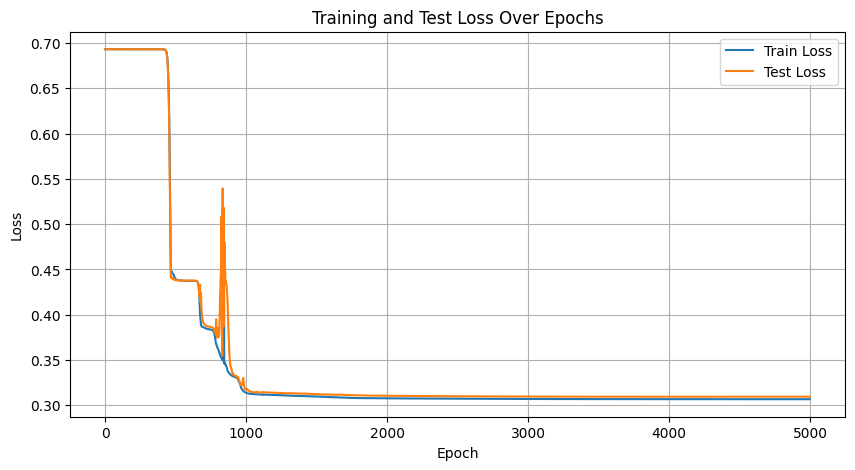

_orig_mod.blocks.0.0.weight
Parameter containing:
tensor([[ 0.1322, -0.2108,  0.9427,  0.0604,  2.5460, -3.7871,  0.9429]],
       requires_grad=True)
_orig_mod.blocks.0.2.a
Parameter containing:
tensor([2.0376], requires_grad=True)
_orig_mod.blocks.0.2.b
Parameter containing:
tensor([-0.7349], requires_grad=True)
_orig_mod.blocks.1.0.weight
Parameter containing:
tensor([[-0.0097,  0.3941,  0.1816,  0.0222, -1.4279, -0.7486,  2.1455,  0.2707]],
       requires_grad=True)
_orig_mod.blocks.1.2.a
Parameter containing:
tensor([1.9984], requires_grad=True)
_orig_mod.blocks.1.2.b
Parameter containing:
tensor([-0.1475], requires_grad=True)
_orig_mod.blocks.2.0.weight
Parameter containing:
tensor([[-0.2380,  0.7810,  6.4645, -0.1376,  0.2202, -0.3311,  0.4731, -0.5718,
         -5.0251]], requires_grad=True)
_orig_mod.blocks.2.2.a
Parameter containing:
tensor([1.0275], requires_grad=True)
_orig_mod.blocks.2.2.b
Parameter containing:
tensor([-3.6439], requires_grad=True)
_orig_mod.blocks.3.0.we

In [26]:
model = torch.compile(StableNN(n=X.shape[1], num_layers=4).to(device))
criterion = nn.CrossEntropyLoss()

optimizers = [
    optim.Rprop(model.parameters(), lr=0.0, step_sizes=(torch.finfo(torch.float32).smallest_normal, torch.inf)) # type: ignore
    # optim.Adam(model.parameters())
]

train(model, criterion, optimizers, epochs=5000)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Layer (type:depth-idx)                   Output Shape              Param #
StableNN                                 [43152, 2]                --
├─BatchNorm1d: 1-1                       [43152, 7]                --
├─ModuleList: 1-2                        --                        --
│    └─Sequential: 2-1                   [43152, 32]               --
│    │    └─Linear: 3-1                  [43152, 32]               224
│    │    └─BatchNorm1d: 3-2             [43152, 32]               --
│    │    └─CustomActivation: 3-3        [43152, 32]               64
│    │    └─BatchNorm1d: 3-4             [43152, 32]               --
│    └─Sequential: 2-2                   [43152, 32]               --
│    │    └─Linear: 3-5                  [43152, 32]               1,248
│    │    └─BatchNorm1d: 3-6             [43152, 32]               --
│    │    └─CustomActivation: 3-7        [43152, 32]               64
│    │    └─BatchNorm1d: 3-8             [43152, 32]               --
│    └─Sequ

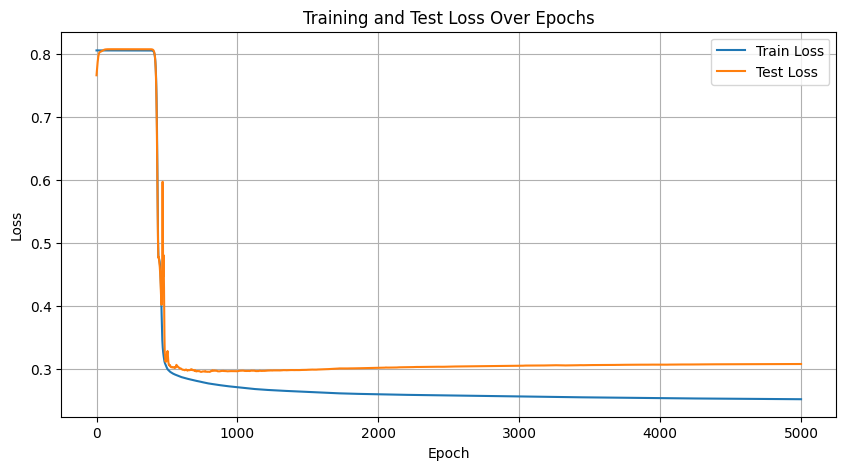

blocks.0.0.weight
Parameter containing:
tensor([[ 0.2914,  0.0494,  0.5110, -0.2368, -0.2896,  0.1835,  0.2065],
        [ 0.1539,  0.2490,  0.0405,  0.1752, -0.1641,  0.0842,  0.0700],
        [ 0.2298,  0.1804, -0.0271,  0.1364,  0.2851, -0.1775, -0.1430],
        [-0.1827, -0.1627,  0.3563,  0.0516,  0.2364,  0.1602,  0.0142],
        [ 0.1752, -0.2988,  0.1258, -0.0654, -0.0661, -0.2648,  0.0946],
        [-0.1508, -0.2726,  0.0785, -0.1066,  0.2346, -0.0688, -0.2341],
        [-0.3247, -0.1997, -0.3656,  0.1429,  0.1440, -0.3608,  0.0009],
        [ 0.3099, -0.2159,  0.2020, -0.1442, -0.0351, -0.2743,  0.3374],
        [-0.0729,  0.3740, -0.1380, -0.0105,  0.2651,  0.3116, -0.2220],
        [ 0.2622, -0.1839, -0.0731, -0.0273, -0.3746,  0.3122, -0.3037],
        [-0.0452,  0.1745, -0.2831,  0.1268, -0.2068,  0.2659,  0.0495],
        [ 0.3675,  0.2819,  0.1097,  0.3349, -0.2278, -0.2259, -0.2753],
        [-0.1503,  0.0769, -0.2347,  0.0773, -0.0337, -0.0522,  0.0994],
        [ 0

In [19]:
model = (StableNN(n=X.shape[1], num_layers=4).to(device))
criterion = nn.CrossEntropyLoss()

optimizers = [
    optim.Rprop(model.parameters(), lr=0.0, step_sizes=(torch.finfo(torch.float32).smallest_normal, torch.inf)) # type: ignore
    # optim.Adam(model.parameters())
]

train(model, criterion, optimizers, epochs=5000)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

In [ ]:
model = (StableNN(n=X.shape[1], num_layers=50).to(device))
criterion = nn.CrossEntropyLoss()

optimizers = [
    # optim.Rprop(model.parameters(), lr=0.0, step_sizes=(torch.finfo(torch.float32).smallest_normal, torch.inf)) # type: ignore
    optim.Adam(model.parameters())
]

train(model, criterion, optimizers, epochs=5000)

for name, param in model.named_parameters(): # type: ignore
    print(name)
    print(param)

Layer (type:depth-idx)                   Output Shape              Param #
StableNN                                 [43152, 2]                --
├─BatchNorm1d: 1-1                       [43152, 7]                --
├─ModuleList: 1-2                        --                        --
│    └─Sequential: 2-1                   [43152, 1]                --
│    │    └─Linear: 3-1                  [43152, 1]                7
│    │    └─BatchNorm1d: 3-2             [43152, 1]                --
│    │    └─CustomActivation: 3-3        [43152, 1]                2
│    │    └─BatchNorm1d: 3-4             [43152, 1]                --
│    └─Sequential: 2-2                   [43152, 1]                --
│    │    └─Linear: 3-5                  [43152, 1]                8
│    │    └─BatchNorm1d: 3-6             [43152, 1]                --
│    │    └─CustomActivation: 3-7        [43152, 1]                2
│    │    └─BatchNorm1d: 3-8             [43152, 1]                --
│    └─Sequential: 

KeyboardInterrupt: 